In [16]:
!pip install -q scikit-image gradio einops

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import math, random, glob, warnings, time, json, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import gradio as gr

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()
print(f"PyTorch {torch.__version__} | Device: {DEVICE} | GPUs: {NUM_GPUS}")
for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB")

^C
ERROR: Operation cancelled by user
PyTorch 2.10.0+cu128 | Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | VRAM: 15.6 GB
  GPU 1: Tesla T4 | VRAM: 15.6 GB


config

In [17]:
class Config:
    TRAIN_DIR      = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train"
    VAL_DIR        = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid"
    IMAGE_SIZE     = 64
    MAX_TRAIN      = 10000
    MAX_VAL        = 1000
    NUM_WORKERS    = 2

    TIMESTEPS      = 500
    BETA_SCHEDULE  = "cosine"

    BASE_CH        = 64
    CH_MULTS       = (1, 2, 4)
    ATTN_RES       = (16,)
    NUM_RES_BLOCKS = 2
    DROPOUT        = 0.1

    EPOCHS         = 100
    BATCH_SIZE     = 16
    LR             = 5e-5
    EMA_DECAY      = 0.9999
    GRAD_CLIP      = 0.5
    WARMUP_STEPS   = 500

    DDIM_STEPS     = 100
    NUM_GENERATED  = 5
    PATIENCE       = 20
    SHOW_EVERY     = 300

    CKPT_DIR       = "/kaggle/working/ckpt"
    OUT_DIR        = "/kaggle/working/outputs"

os.makedirs(Config.CKPT_DIR, exist_ok=True)
os.makedirs(Config.OUT_DIR,  exist_ok=True)

print("Config ready.")
print(f"  Image size : {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}")
print(f"  Dataset    : {Config.MAX_TRAIN} train / {Config.MAX_VAL} val")
print(f"  U-Net ch   : " + " → ".join(str(Config.BASE_CH * m) for m in Config.CH_MULTS))
print(f"  Timesteps  : {Config.TIMESTEPS}  |  DDIM steps: {Config.DDIM_STEPS}")

Config ready.
  Image size : 64×64
  Dataset    : 10000 train / 1000 val
  U-Net ch   : 64 → 128 → 256
  Timesteps  : 500  |  DDIM steps: 100


Dataset Discovery & EDA

In [18]:
def collect_paths(root, max_n):
    files = glob.glob(os.path.join(root, "**", "*.jpg"), recursive=True) + \
            glob.glob(os.path.join(root, "**", "*.png"), recursive=True)
    random.shuffle(files)
    return files[:max_n]

train_paths = collect_paths(Config.TRAIN_DIR, Config.MAX_TRAIN)
val_paths   = collect_paths(Config.VAL_DIR,   Config.MAX_VAL)
print(f"Train: {len(train_paths):,}  |  Val: {len(val_paths):,}")

sizes = [Image.open(p).size for p in random.sample(train_paths, min(100, len(train_paths)))]
arr   = np.array(sizes)
print(f"Native resolution — W: {arr[:,0].min()}–{arr[:,0].max()}  H: {arr[:,1].min()}–{arr[:,1].max()}")

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.patch.set_facecolor("#0d0d0d")
for ax, p in zip(axes.flat, random.sample(train_paths, 16)):
    ax.imshow(Image.open(p).convert("RGB").resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)))
    ax.axis("off")
fig.suptitle(f"CelebA-HQ Sample Grid — {len(train_paths):,} training images", color="white", fontsize=12)
plt.tight_layout(pad=0.3)
plt.savefig(f"{Config.OUT_DIR}/eda_grid.png", dpi=110, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

KeyboardInterrupt: 

Dataset & DataLoader

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, paths, size):
        self.paths = paths
        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

train_ds = FaceDataset(train_paths, Config.IMAGE_SIZE)
val_ds   = FaceDataset(val_paths,   Config.IMAGE_SIZE)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,
                          num_workers=Config.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False,
                          num_workers=Config.NUM_WORKERS, pin_memory=True)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}")

Cosine Noise Schedule

In [ ]:
class NoiseSchedule:
    def __init__(self, T, schedule="cosine", device=DEVICE):
        self.T = T
        self.device = device
        if schedule == "cosine":
            steps = torch.arange(T + 1, dtype=torch.float64)
            ft    = torch.cos(((steps / T) + 0.008) / 1.008 * math.pi / 2) ** 2
            acp   = ft / ft[0]
            betas = (1 - acp[1:] / acp[:-1]).clamp(0, 0.999).float()
        else:
            betas = torch.linspace(1e-4, 0.02, T).float()

        alphas    = 1.0 - betas
        acp       = torch.cumprod(alphas, dim=0)
        acp_prev  = F.pad(acp[:-1], (1, 0), value=1.0)

        self.betas              = betas.to(device)
        self.alphas             = alphas.to(device)
        self.alphas_cumprod     = acp.to(device)
        self.alphas_cumprod_prev= acp_prev.to(device)
        self.sqrt_acp           = acp.sqrt().to(device)
        self.sqrt_one_minus_acp = (1 - acp).sqrt().to(device)
        self.posterior_var      = (betas * (1 - acp_prev) / (1 - acp)).to(device)

    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        s1 = self.sqrt_acp[t][:, None, None, None]
        s2 = self.sqrt_one_minus_acp[t][:, None, None, None]
        return s1 * x0 + s2 * noise, noise

    @torch.no_grad()
    def ddim_sample(self, model, shape, num_steps=100, eta=0.0, return_intermediates=False):
        model.eval()
        ts      = torch.linspace(self.T - 1, 0, num_steps, dtype=torch.long, device=self.device)
        x       = torch.randn(shape, device=self.device)
        frames  = []
        n_collect  = min(5, num_steps)
        collect_at = set(np.linspace(0, num_steps - 1, n_collect, dtype=int).tolist())

        for i, t in enumerate(ts):
            t_batch    = t.expand(shape[0])
            pred_noise = model(x, t_batch)
            acp_t      = self.alphas_cumprod[t]
            acp_tp     = self.alphas_cumprod[ts[i+1]] if i+1 < len(ts) else torch.tensor(1.0, device=self.device)

            x0_pred = (x - (1 - acp_t).sqrt() * pred_noise) / acp_t.sqrt()
            x0_pred = x0_pred.clamp(-1, 1)

            dir_coef = (1 - acp_tp).sqrt()
            x        = acp_tp.sqrt() * x0_pred + dir_coef * pred_noise

            if return_intermediates and i in collect_at:
                frames.append(x.cpu())

        if return_intermediates:
            frames.append(x.cpu())
            return x.cpu(), frames
        return x.cpu()

schedule = NoiseSchedule(Config.TIMESTEPS, Config.BETA_SCHEDULE)
print("Noise schedule ready.")
print(f"  β range : {schedule.betas.min():.5f} → {schedule.betas.max():.4f}")
print(f"  ᾱ_T     : {schedule.alphas_cumprod[-1]:.5f}")

 Forward Diffusion Visualization (5 steps)

In [ ]:
ref_img = next(iter(train_loader))[:1].to(DEVICE)
forward_ts = [0, int(Config.TIMESTEPS*0.2), int(Config.TIMESTEPS*0.4),
              int(Config.TIMESTEPS*0.7), Config.TIMESTEPS-1]

def to_pil(t):
    img = ((t.cpu().squeeze().permute(1,2,0).numpy() + 1) / 2).clip(0, 1)
    return (img * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.patch.set_facecolor("#0d0d0d")
axes[0].imshow(to_pil(ref_img[0])); axes[0].set_title("Original", color="white"); axes[0].axis("off")
for ax, t in zip(axes[1:], forward_ts):
    xt, _ = schedule.q_sample(ref_img, torch.tensor([t], device=DEVICE))
    ax.imshow(to_pil(xt[0])); ax.set_title(f"t={t}", color="white"); ax.axis("off")
fig.suptitle("Forward Diffusion — Progressive Noising", color="white", fontsize=12)
plt.tight_layout(pad=0.3)
plt.savefig(f"{Config.OUT_DIR}/forward_diffusion.png", dpi=110, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

U-Net Model

In [ ]:
def get_groups(ch):
    for g in [32, 16, 8, 4, 2, 1]:
        if ch % g == 0: return g

class SinusoidalEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        emb  = t.float()[:, None] * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.norm1  = nn.GroupNorm(get_groups(in_ch), in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(get_groups(out_ch), out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, out_ch * 2))
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.SiLU()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        sc, sh = self.t_proj(t_emb).chunk(2, dim=-1)
        h = self.norm2(h) * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        h = self.drop(self.act(h))
        h = self.conv2(h)
        return h + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(get_groups(ch), ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, -1).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).view(B, C, H, W)

class UNet(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        base  = Config.BASE_CH
        t_dim = base * 4
        c1, c2, c3 = base, base*2, base*4

        self.t_emb = nn.Sequential(
            SinusoidalEmb(t_dim),
            nn.Linear(t_dim, t_dim*2), nn.SiLU(),
            nn.Linear(t_dim*2, t_dim)
        )

        self.init_conv = nn.Conv2d(in_ch, c1, 3, padding=1)

        self.e1a = ResBlock(c1, c1, t_dim)
        self.e1b = ResBlock(c1, c1, t_dim)
        self.down1 = nn.Conv2d(c1, c1, 4, 2, 1)   

        self.e2a = ResBlock(c1, c2, t_dim)
        self.e2b = ResBlock(c2, c2, t_dim)
        self.down2 = nn.Conv2d(c2, c2, 4, 2, 1)   

        self.e3a   = ResBlock(c2, c3, t_dim)
        self.e3b   = ResBlock(c3, c3, t_dim)
        self.attn3 = SelfAttention(c3)

        self.mid1    = ResBlock(c3, c3, t_dim)
        self.mid_att = SelfAttention(c3)
        self.mid2    = ResBlock(c3, c3, t_dim)

        self.dec3a = ResBlock(c3+c3, c3, t_dim)
        self.dec3b = ResBlock(c3,    c3, t_dim)
        self.up2   = nn.ConvTranspose2d(c3, c3, 4, 2, 1)  

        self.dec2a = ResBlock(c3+c2, c2, t_dim)
        self.dec2b = ResBlock(c2,    c2, t_dim)
        self.up1   = nn.ConvTranspose2d(c2, c2, 4, 2, 1)  

        self.dec1a = ResBlock(c2+c1, c1, t_dim)
        self.dec1b = ResBlock(c1,    c1, t_dim)

        self.out_norm = nn.GroupNorm(get_groups(c1), c1)
        self.out_conv = nn.Conv2d(c1, in_ch, 1)

    def forward(self, x, t):
        te = self.t_emb(t)
        x  = self.init_conv(x)        

        s1 = self.e1b(self.e1a(x,  te), te)          
        x  = self.down1(s1)                           
        s2 = self.e2b(self.e2a(x,  te), te)          
        x  = self.down2(s2)                           
        s3 = self.attn3(self.e3b(self.e3a(x, te), te))  

        m  = self.mid2(self.mid_att(self.mid1(s3, te)), te) 

        x  = self.dec3b(self.dec3a(torch.cat([m,  s3], 1), te), te) 
        x  = self.up2(x)                                             
        x  = self.dec2b(self.dec2a(torch.cat([x,  s2], 1), te), te)  
        x  = self.up1(x)                                              
        x  = self.dec1b(self.dec1a(torch.cat([x,  s1], 1), te), te)  

        return self.out_conv(F.silu(self.out_norm(x)))


model = UNet().to(DEVICE)
if NUM_GPUS > 1: model = nn.DataParallel(model)
core_model = model.module if NUM_GPUS > 1 else model
print(f"U-Net params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

EMA & Checkpoint Utilities

In [ ]:
class EMA:
    def __init__(self, model, decay):
        self.decay  = decay
        self.shadow = {k: v.clone().float().to(DEVICE) for k, v in model.state_dict().items()}
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v.float().to(DEVICE)
    def apply(self, model):
        model.load_state_dict({k: v.to(DEVICE) for k, v in self.shadow.items()})

META = os.path.join(Config.CKPT_DIR, "meta.json")

def save_ckpt(epoch, best_val, no_imp, tr_losses, vl_losses):
    torch.save(core_model.state_dict(), f"{Config.CKPT_DIR}/last.pth")
    torch.save(core_model.state_dict(), f"{Config.CKPT_DIR}/best_tmp.pth")
    torch.save({k: v.cpu() for k, v in ema.shadow.items()}, f"{Config.CKPT_DIR}/ema.pth")
    with open(META, "w") as f:
        json.dump({"epoch": epoch, "best_val": best_val, "no_imp": no_imp,
                   "tr": tr_losses, "vl": vl_losses}, f)

def load_ckpt():
    if not os.path.exists(META):
        print("No checkpoint. Starting fresh.")
        return 0, float("inf"), 0, [], []
    with open(META) as f: m = json.load(f)
    lp = f"{Config.CKPT_DIR}/last.pth"
    ep = f"{Config.CKPT_DIR}/ema.pth"
    if os.path.exists(lp):
        sd = torch.load(lp, map_location=DEVICE)
        first_key = next(iter(sd.keys()))
        if first_key.startswith("module."):
            core_model.load_state_dict({k.replace("module.", ""): v for k, v in sd.items()})
        else:
            core_model.load_state_dict(sd)
        if NUM_GPUS > 1:
            model.module.load_state_dict(core_model.state_dict())
        else:
            model.load_state_dict(core_model.state_dict())
        print(f"Resumed from epoch {m['epoch']}")
    if os.path.exists(ep):
        sd = torch.load(ep, map_location=DEVICE)
        first_key = next(iter(sd.keys()))
        if first_key.startswith("module."):
            ema.shadow = {k.replace("module.", ""): v.to(DEVICE) for k, v in sd.items()}
        else:
            ema.shadow = {k: v.to(DEVICE) for k, v in sd.items()}
    return m["epoch"], m["best_val"], m["no_imp"], m["tr"], m["vl"]

ema = EMA(core_model, Config.EMA_DECAY)

Training Loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)

start_epoch, best_val, no_imp, tr_losses, vl_losses = load_ckpt()
global_step = start_epoch * len(train_loader)

for epoch in range(start_epoch, Config.EPOCHS):
    model.train(); ep_loss = 0.0

    for x0 in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}", leave=False):
        x0    = x0.to(DEVICE)
        t     = torch.randint(0, Config.TIMESTEPS, (x0.size(0),), device=DEVICE)
        noise = torch.randn_like(x0)
        xt, _ = schedule.q_sample(x0, t, noise)
        pred  = model(xt, t)
        loss  = F.mse_loss(pred, noise)

        if torch.isnan(loss) or torch.isinf(loss):
            print("Bad loss, skipping batch"); continue

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
        optimizer.step()
        ema.update(core_model)
        ep_loss     += loss.item()
        global_step += 1

        if global_step < Config.WARMUP_STEPS:
            lr = Config.LR * global_step / Config.WARMUP_STEPS
            for pg in optimizer.param_groups: pg["lr"] = lr

    model.eval(); vl = 0.0
    with torch.no_grad():
        for x0 in val_loader:
            x0 = x0.to(DEVICE)
            t  = torch.randint(0, Config.TIMESTEPS, (x0.size(0),), device=DEVICE)
            xt, noise = schedule.q_sample(x0, t)
            vl += F.mse_loss(model(xt, t), noise).item()

    tr_l = ep_loss / len(train_loader)
    vl_l = vl      / len(val_loader)
    tr_losses.append(tr_l); vl_losses.append(vl_l)
    scheduler.step()

    if vl_l < best_val:
        best_val = vl_l; no_imp = 0
        torch.save(model.state_dict(), f"{Config.CKPT_DIR}/best.pth")
        print(f"  *** best model saved  val={vl_l:.5f} ***")
    else:
        no_imp += 1

    save_ckpt(epoch + 1, best_val, no_imp, tr_losses, vl_losses)
    print(f"Epoch {epoch+1:3d}  train={tr_l:.5f}  val={vl_l:.5f}  patience={no_imp}/{Config.PATIENCE}")

    if (epoch + 1) % 5 == 0:
        core_model.eval()
        with torch.no_grad():
            sample_imgs, _ = schedule.ddim_sample(core_model,
                                                   (5, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE),
                                                   num_steps=50, eta=0.0,
                                                   return_intermediates=True)
        fig, axes = plt.subplots(1, 5, figsize=(18, 4))
        fig.patch.set_facecolor("#0d0d0d")
        for i, ax in enumerate(axes):
            ax.imshow(to_pil(sample_imgs[i])); ax.axis("off")
            ax.set_title(f"Sample {i+1}", color="white", fontsize=10)
        fig.suptitle(f"Generated Samples — Epoch {epoch+1}", color="white", fontsize=12)
        plt.tight_layout(pad=0.3)
        plt.savefig(f"{Config.OUT_DIR}/samples_epoch_{epoch+1}.png", dpi=100,
                    bbox_inches="tight", facecolor="#0d0d0d")
        plt.show()

    if no_imp >= Config.PATIENCE:
        print("Early stopping."); break

plt.figure(figsize=(7, 3))
plt.plot(tr_losses, label="train"); plt.plot(vl_losses, label="val")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend(); plt.title("Training Curve")
plt.tight_layout()
plt.savefig(f"{Config.OUT_DIR}/loss_curve.png", dpi=100)
plt.show()

Load Best & Generate 5 Images

In [19]:
def load_weights(path, model):
    sd = torch.load(path, map_location=DEVICE)
    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    model.load_state_dict(sd)

load_weights(f"{Config.CKPT_DIR}/best.pth", core_model)
print("Loaded.")

Loaded.


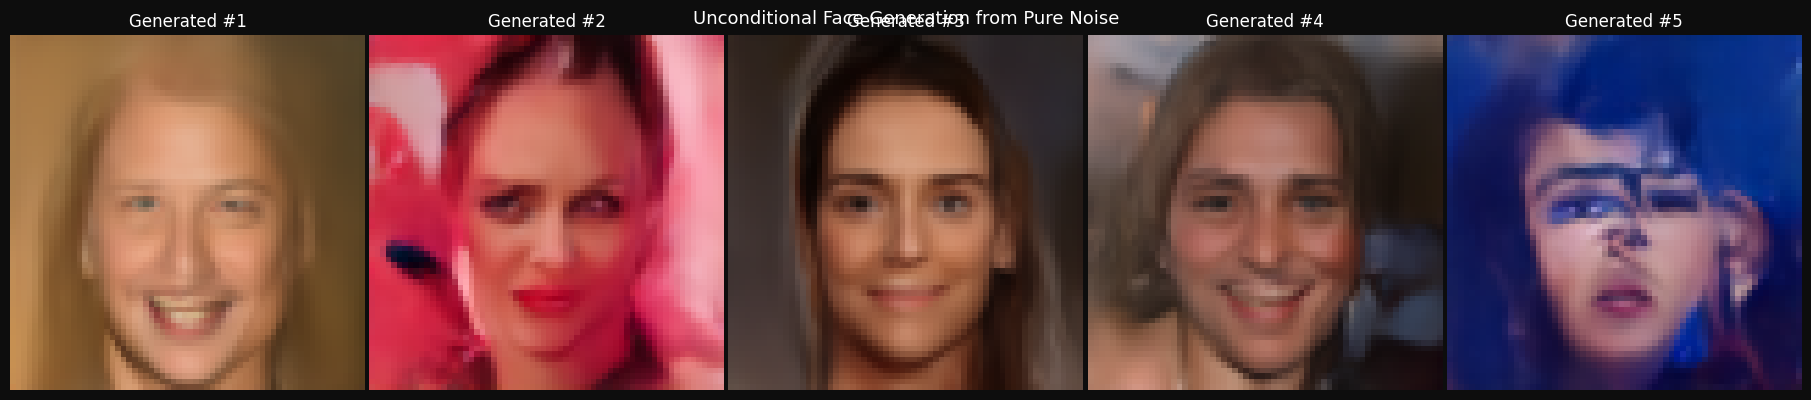

In [20]:
def load_weights(path, model):
    sd = torch.load(path, map_location=DEVICE)
    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    model.load_state_dict(sd)

load_weights(f"{Config.CKPT_DIR}/best.pth", core_model)
core_model.eval()

shape = (Config.NUM_GENERATED, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE)
gen_images, frames = schedule.ddim_sample(core_model, shape,
                                          num_steps=Config.DDIM_STEPS,
                                          eta=0.0, return_intermediates=True)

fig, axes = plt.subplots(1, Config.NUM_GENERATED, figsize=(18, 4))
fig.patch.set_facecolor("#0d0d0d")
for i, ax in enumerate(axes):
    ax.imshow(to_pil(gen_images[i])); ax.axis("off"); ax.set_title(f"Generated #{i+1}", color="white")
fig.suptitle("Unconditional Face Generation from Pure Noise", color="white", fontsize=13)
plt.tight_layout(pad=0.3)
plt.savefig(f"{Config.OUT_DIR}/generated_5.png", dpi=120, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

 Image Reconstruction + PSNR/SSIM

PSNR : 24.20 dB
SSIM : 0.7447


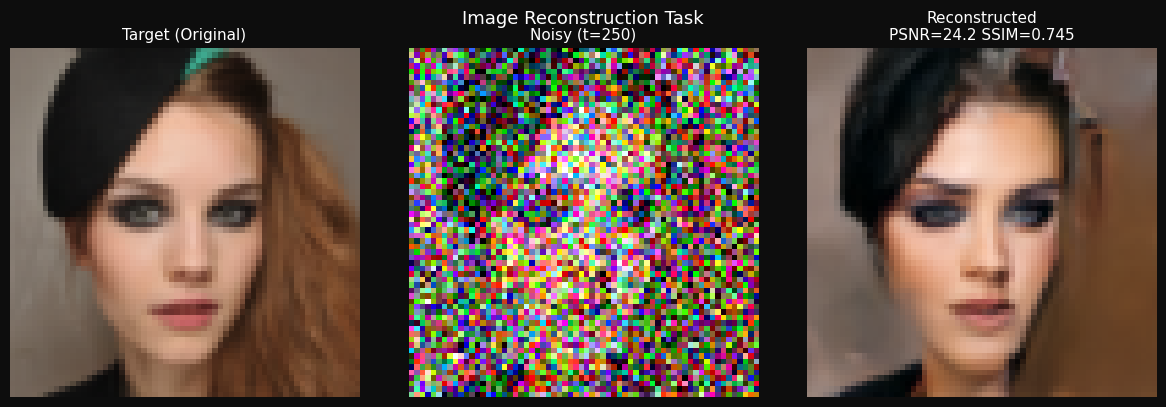

In [21]:
def load_weights(path, model):
    sd = torch.load(path, map_location=DEVICE)
    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    model.load_state_dict(sd)

load_weights(f"{Config.CKPT_DIR}/best.pth", core_model)
core_model.eval()

target_clean = next(iter(val_loader))[:1].to(DEVICE)

recon_steps  = 250
t_start      = torch.tensor([recon_steps - 1], device=DEVICE)
noisy_target, _ = schedule.q_sample(target_clean, t_start)

ts      = torch.linspace(recon_steps - 1, 0, recon_steps, dtype=torch.long, device=DEVICE)
xt      = noisy_target.clone()

with torch.no_grad():
    for i, t in enumerate(ts):
        t_batch    = t.expand(1)
        pred_noise = core_model(xt, t_batch)
        acp_t      = schedule.alphas_cumprod[t]
        acp_tp     = schedule.alphas_cumprod[ts[i+1]] if i+1 < len(ts) else torch.tensor(1.0, device=DEVICE)
        x0_pred    = (xt - (1 - acp_t).sqrt() * pred_noise) / acp_t.sqrt()
        x0_pred    = x0_pred.clamp(-1, 1)
        xt         = acp_tp.sqrt() * x0_pred + (1 - acp_tp).sqrt() * pred_noise

xt_recon = xt.cpu()

tgt_np   = to_pil(target_clean[0]).astype(np.float32) / 255.0
recon_np = to_pil(xt_recon[0]).astype(np.float32)     / 255.0

psnr = peak_signal_noise_ratio(tgt_np, recon_np, data_range=1.0)
ssim = structural_similarity(tgt_np, recon_np, channel_axis=2, data_range=1.0)
print(f"PSNR : {psnr:.2f} dB")
print(f"SSIM : {ssim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor("#0d0d0d")
for ax, img, title in zip(axes,
    [to_pil(target_clean[0]), to_pil(noisy_target[0]), to_pil(xt_recon[0])],
    ["Target (Original)", f"Noisy (t={recon_steps})", f"Reconstructed\nPSNR={psnr:.1f} SSIM={ssim:.3f}"]):
    ax.imshow(img); ax.set_title(title, color="white", fontsize=11); ax.axis("off")
fig.suptitle("Image Reconstruction Task", color="white", fontsize=13)
plt.tight_layout(pad=0.3)
plt.savefig(f"{Config.OUT_DIR}/reconstruction.png", dpi=120, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

Full Pipeline Visualization

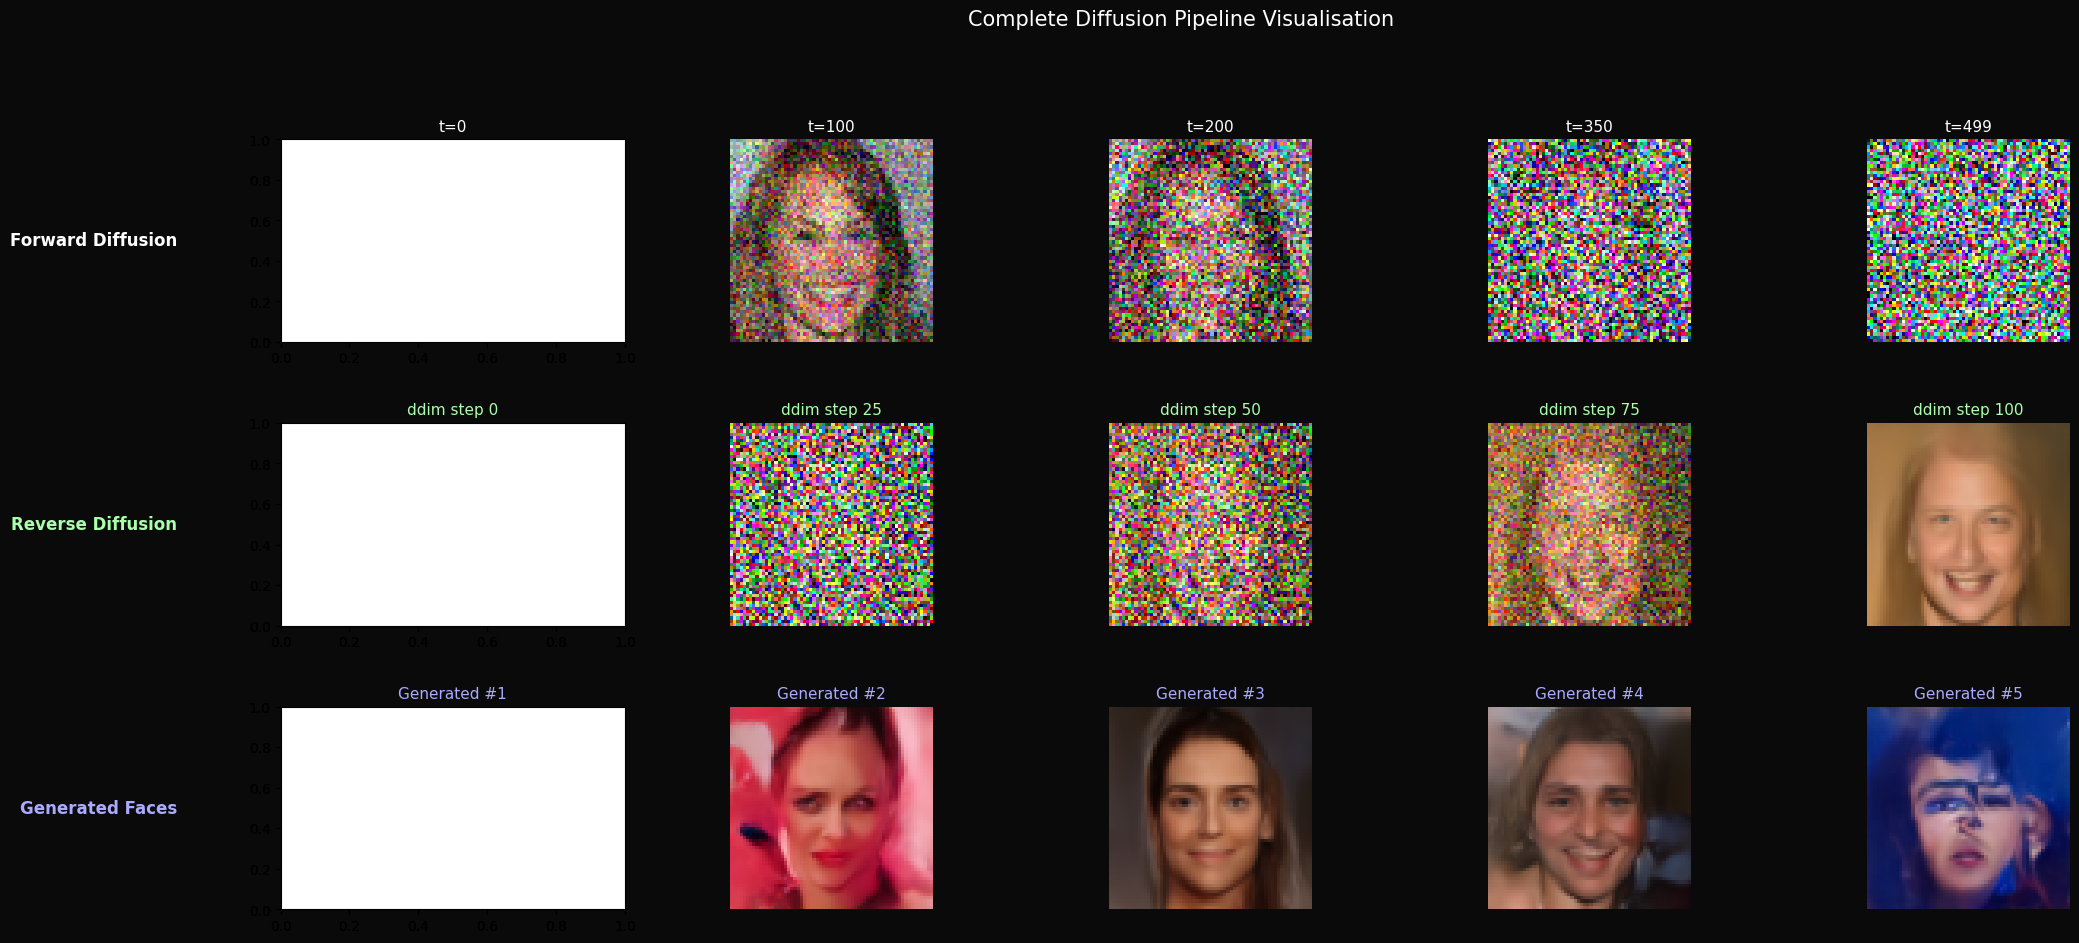

In [22]:
forward_ts = [0, int(Config.TIMESTEPS*0.2), int(Config.TIMESTEPS*0.4),
              int(Config.TIMESTEPS*0.7), Config.TIMESTEPS - 1]

fig = plt.figure(figsize=(24, 10))
gs  = gridspec.GridSpec(3, 5, hspace=0.4, wspace=0.1)
fig.patch.set_facecolor("#0a0a0a")

for col, t in enumerate(forward_ts):
    xt, _ = schedule.q_sample(ref_img, torch.tensor([t], device=DEVICE))
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(to_pil(xt[0])); ax.axis("off"); ax.set_title(f"t={t}", color="white", fontsize=11)

rev_frames_display = frames[:5] if len(frames) >= 5 else frames
for col, frame in enumerate(rev_frames_display):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(to_pil(frame[0])); ax.axis("off")
    ax.set_title(f"ddim step {col * (Config.DDIM_STEPS // 4)}", color="#aaffaa", fontsize=11)

for col in range(5):
    ax = fig.add_subplot(gs[2, col])
    ax.imshow(to_pil(gen_images[col])); ax.axis("off")
    ax.set_title(f"Generated #{col+1}", color="#aaaaff", fontsize=11)

for row, (label, color) in enumerate([("Forward Diffusion","white"),
                                       ("Reverse Diffusion","#aaffaa"),
                                       ("Generated Faces","#aaaaff")]):
    fig.add_subplot(gs[row, 0]).text(-0.3, 0.5, label, transform=fig.add_subplot(gs[row,0]).transAxes,
                                     va="center", ha="right", fontsize=12, color=color, fontweight="bold")

fig.suptitle("Complete Diffusion Pipeline Visualisation", color="white", fontsize=15, y=1.01)
plt.savefig(f"{Config.OUT_DIR}/full_pipeline.png", dpi=120, bbox_inches="tight", facecolor="#0a0a0a")
plt.show()